<a href="https://colab.research.google.com/github/Ouad90/retail-sales-forecasting/blob/main/W2_Statistical_Time_Series_Analysis_FIXED_executed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 2 — Statistical Time Series Analysis + Introductory Forecasting Models

## Objective
Understand the mathematical properties of the daily sales series and build simple statistical benchmark models.

## What this notebook covers
1. Prepare the cleaned time series from Week 1
2. Stationarity analysis: rolling statistics, ADF, KPSS
3. Decomposition: trend, seasonality, residuals
4. Autocorrelation: ACF and PACF
5. Trend and seasonality detection
6. Baseline forecasting models
7. Additional Week 2 models from previous work:
   - SARIMAX / ARIMA-style model
   - Exponential Smoothing / Holt-Winters
   - Prophet, if installed
8. Model comparison and final interpretation


## 1. Import Libraries

In [ ]:
import os
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing, Holt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True


## 2. Load the Cleaned Week 1 Dataset

We start from the cleaned Week 1 file. If it is not available, the notebook falls back to the raw `timeseries.csv`.

In [ ]:
from google.colab import files

# Upload file
uploaded = files.upload()

Saving week1_clean_full.csv to week1_clean_full (1).csv


In [ ]:
CLEAN_PATH = "week1_clean_full.csv"
RAW_PATH = "timeseries.csv"

if os.path.exists(CLEAN_PATH):
    df = pd.read_csv(CLEAN_PATH)
    print(f"Loaded: {CLEAN_PATH}")
elif os.path.exists(RAW_PATH):
    df = pd.read_csv(RAW_PATH)
    print(f"Loaded fallback: {RAW_PATH}")
else:
    raise FileNotFoundError("No input data found. Please place week1_clean_full.csv or timeseries.csv in the same folder.")

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)
print(df.shape)
df.head()


Loaded: week1_clean_full.csv
(454, 33)


,date,unit_sales,dcoilwtico,holiday_count,is_national_holiday,is_regional_holiday,is_local_holiday,holiday_description,is_holiday,year,...,unit_sales_lag_30,unit_sales_roll_mean_7,unit_sales_roll_std_7,unit_sales_roll_mean_14,unit_sales_roll_std_14,unit_sales_roll_mean_30,unit_sales_roll_std_30,oil_lag_1,oil_lag_7,oil_roll_mean_7
0,2013-01-02,582.0,93.140000,0,0,0,0,No holiday,0,2013,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2013-01-03,310.0,92.970000,0,0,0,0,No holiday,0,2013,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,93.140000,NaN,NaN
2,2013-01-04,338.0,93.120000,0,0,0,0,No holiday,0,2013,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,92.970000,NaN,NaN
3,2013-01-05,654.0,93.146667,1,1,0,0,Recupero puente Navidad,1,2013,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,93.120000,NaN,NaN
4,2013-01-06,979.0,93.173333,0,0,0,0,No holiday,0,2013,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,93.146667,NaN,NaN


## 3. Prepare the Daily Time Series

For statistical time series analysis, the date becomes the index and the target variable is `unit_sales`.

We also enforce daily frequency to make sure there are no missing dates.

In [ ]:
ts_df = df[["date", "unit_sales"]].copy()
ts_df = ts_df.groupby("date", as_index=False)["unit_sales"].sum()
ts_df = ts_df.set_index("date").sort_index()

# Force daily frequency
ts_df = ts_df.asfreq("D")
missing_before = ts_df["unit_sales"].isna().sum()
ts_df["unit_sales"] = ts_df["unit_sales"].interpolate().ffill().bfill()

ts = ts_df["unit_sales"]

print("Start date:", ts.index.min())
print("End date:", ts.index.max())
print("Number of observations:", len(ts))
print("Missing values before filling:", missing_before)
print("Missing values after filling:", ts.isna().sum())
ts.describe()


Start date: 2013-01-02 00:00:00
End date: 2014-03-31 00:00:00
Number of observations: 454
Missing values before filling: 0
Missing values after filling: 0


,unit_sales
count,454.000000
mean,477.975771
std,173.408453
min,0.000000
25%,356.500000
50%,443.500000
75%,576.750000
max,1203.000000


## 4. Visualize the Original Series

**Aim:** Get the first impression of sales behavior over time.

We look for spikes, drops, trend, and repeated patterns.

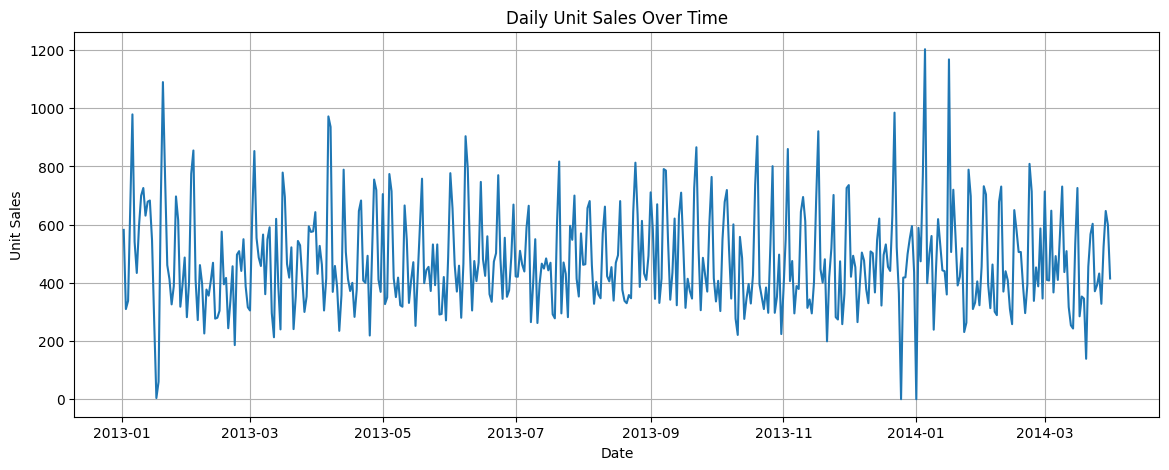

In [ ]:
plt.figure()
plt.plot(ts.index, ts.values)
plt.title("Daily Unit Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.show()


###interpretation

Sales move up and down a lot. There are clear high-sales days and low-sales days.

The series does not look perfectly flat, but it also does not show a very strong long-term upward or downward trend.

So the first impression is:

Sales fluctuate regularly, probably with weekly patterns.

## 5. Rolling Mean and Rolling Standard Deviation

**Aim:** Visually check whether the average and variability change strongly over time.

A stationary series should have a relatively stable mean and variance.

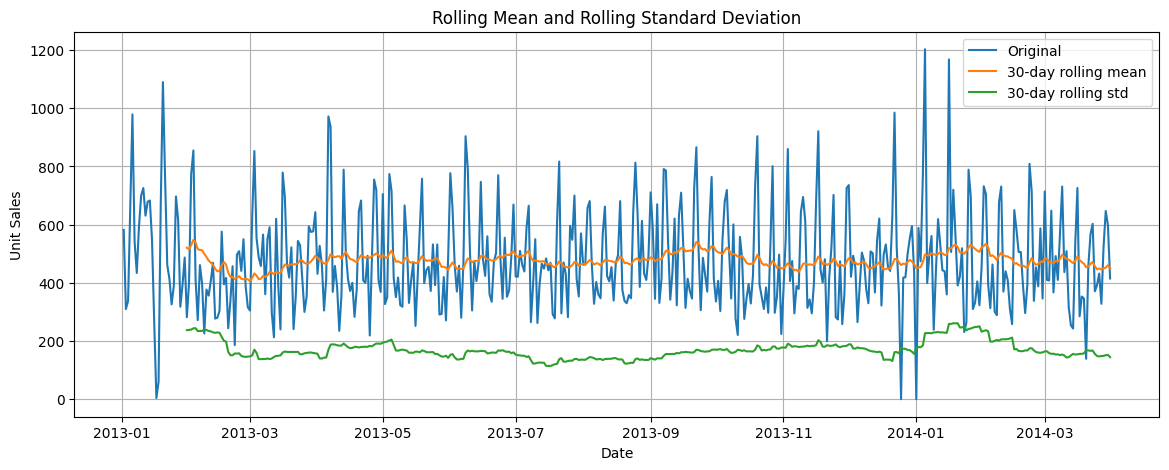

In [ ]:
rolling_window = 30
rolling_mean = ts.rolling(rolling_window).mean()
rolling_std = ts.rolling(rolling_window).std()

plt.figure()
plt.plot(ts, label="Original")
plt.plot(rolling_mean, label="30-day rolling mean")
plt.plot(rolling_std, label="30-day rolling std")
plt.title("Rolling Mean and Rolling Standard Deviation")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.legend()
plt.show()


###Interpretation:
**What is rolling mean?**

It is the average sales over the last 30 days.

**What is rolling standard deviation?**

It shows how much sales vary over the last 30 days.

**interpretation**

If the rolling mean stays roughly stable, the average sales level is stable.

If the rolling standard deviation stays roughly stable, the variability is stable.

Here, the rolling mean and variability do not explode or strongly drift.

So:

The series looks fairly stable, which supports stationarity.

## 6. Stationarity Analysis — ADF Test

The ADF test checks whether the series is stationary.

- H0: the series is non-stationary
- H1: the series is stationary

If p-value ≤ 0.05, we reject H0 and conclude the series is stationary.

In [ ]:
def run_adf(series, name="Series"):
    series = series.dropna()
    result = adfuller(series)
    print(f"ADF Test for {name}")
    print("ADF Statistic:", result[0])
    print("P-value:", result[1])
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"  {key}: {value}")
    if result[1] <= 0.05:
        print("Conclusion: Series is stationary (reject H0).")
    else:
        print("Conclusion: Series is non-stationary (fail to reject H0).")

run_adf(ts, "Original Unit Sales")


ADF Test for Original Unit Sales
ADF Statistic: -5.343772240147953
P-value: 4.441049433078314e-06
Critical Values:
  1%: -3.4454725477848998
  5%: -2.8682072297316794
  10%: -2.570321396485665
Conclusion: Series is stationary (reject H0).


###Interpretation:
p-value < 0.05

The sales series is stationary.

This means we probably do not need strong differencing before ARIMA-style modeling.

## 7. Stationarity Analysis — KPSS Test

KPSS is useful because it has the opposite null hypothesis.

- H0: the series is stationary
- H1: the series is non-stationary

If p-value > 0.05, we do not reject H0, so stationarity is supported.

In [ ]:
def run_kpss(series, name="Series"):
    series = series.dropna()
    statistic, p_value, lags, critical_values = kpss(series, regression="c", nlags="auto")
    print(f"KPSS Test for {name}")
    print("KPSS Statistic:", statistic)
    print("P-value:", p_value)
    print("Lags:", lags)
    print("Critical Values:")
    for key, value in critical_values.items():
        print(f"  {key}: {value}")
    if p_value > 0.05:
        print("Conclusion: Series is stationary (fail to reject H0).")
    else:
        print("Conclusion: Series may be non-stationary (reject H0).")

run_kpss(ts, "Original Unit Sales")


KPSS Test for Original Unit Sales
KPSS Statistic: 0.03901989676849176
P-value: 0.1
Lags: 14
Critical Values:
  10%: 0.347
  5%: 0.463
  2.5%: 0.574
  1%: 0.739
Conclusion: Series is stationary (fail to reject H0).


###Interpretation:

KPSS p-value: 0.100000

--> Series is stationary.

## 8. Differencing Check

Differencing means looking at the change from one day to the next.

Even when the original series is already stationary, this step helps us understand day-to-day movement.

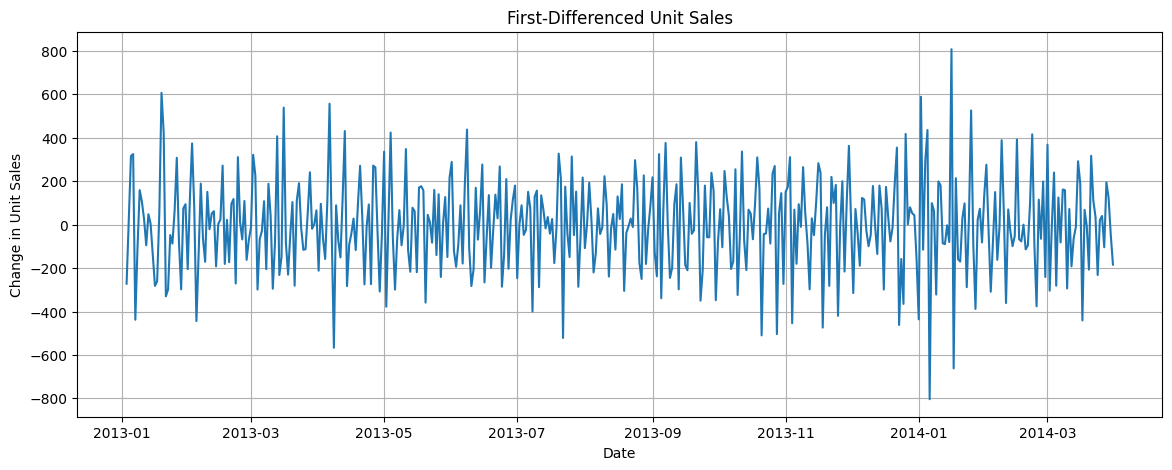

ADF Test for First-Differenced Unit Sales
ADF Statistic: -14.37584985037066
P-value: 9.327546183921034e-27
Critical Values:
  1%: -3.445299682487321
  5%: -2.8681312035123967
  10%: -2.570280872933884
Conclusion: Series is stationary (reject H0).


In [ ]:
ts_diff = ts.diff().dropna()

plt.figure()
plt.plot(ts_diff)
plt.title("First-Differenced Unit Sales")
plt.xlabel("Date")
plt.ylabel("Change in Unit Sales")
plt.show()

run_adf(ts_diff, "First-Differenced Unit Sales")


###Interpretation
This plot shows how much sales changed from one day to the next.

It fluctuates around zero, meaning some days sales increase, other days sales decrease.

The ADF test on the differenced series also says stationary.

But since the original series was already stationary, differencing may not be necessary

## 9. Decomposition — Weekly Period

**Aim:** Separate the sales series into:

- Trend: long-term movement
- Seasonality: repeating weekly pattern
- Residual: leftover noise

Because the data is daily and retail sales often repeat weekly, we use `period=7`.

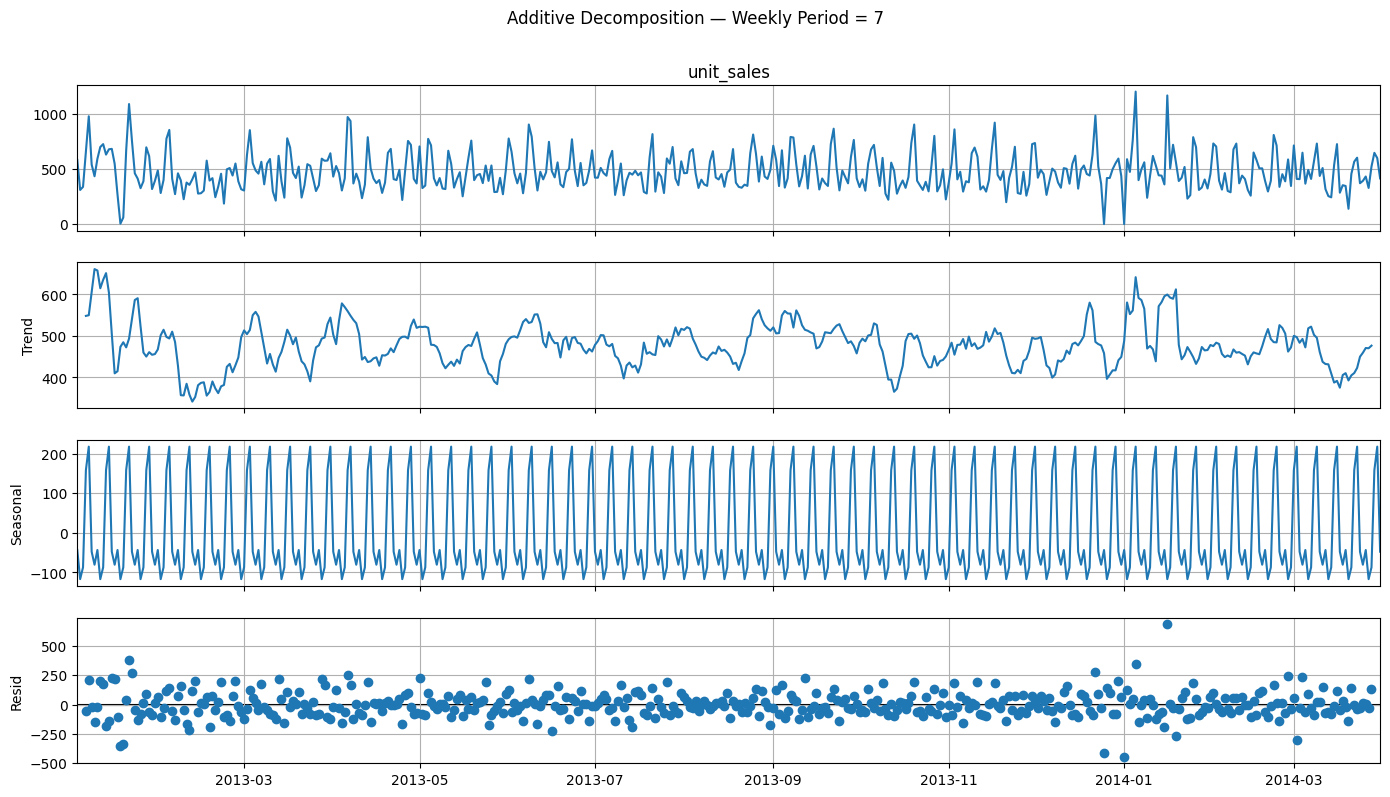

In [ ]:
decomp_add = seasonal_decompose(ts, model="additive", period=7)
fig = decomp_add.plot()
fig.set_size_inches(14, 8)
plt.suptitle("Additive Decomposition — Weekly Period = 7", y=1.02)
plt.show()


1. Observed: The original sales.

2. Trend: The smooth long-term movement. It helps us answer:

Is the business slowly growing or declining?

3. Seasonal: The repeating weekly pattern.

4. Residual: The leftover noise after removing trend and seasonality.

**Simple interpretation**

- The trend changes gradually, but no huge long-term increase exists.
--> only moderate trend exists.

- The seasonal plot helps us see that sales are not random.  
--> There is a weekly structure in the data.

- After removing:
trend
seasonality
the remaining noise look random.
-->most structure has been extracted successfully.

## 10. Trend Detection

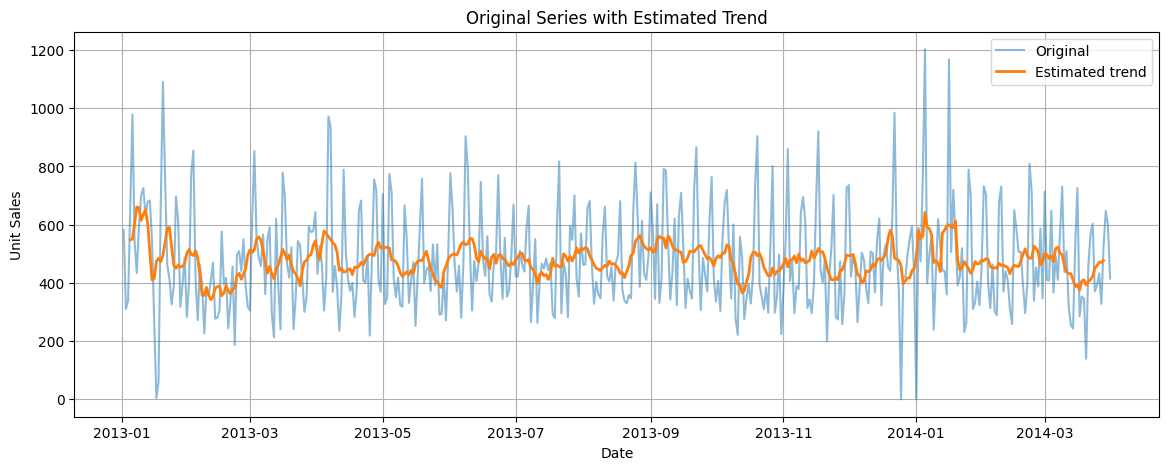

Trend mean: 477.49
Trend min: 341.71
Trend max: 661.0


In [ ]:
trend = decomp_add.trend

plt.figure()
plt.plot(ts, label="Original", alpha=0.5)
plt.plot(trend, label="Estimated trend", linewidth=2)
plt.title("Original Series with Estimated Trend")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.legend()
plt.show()

print("Trend mean:", round(trend.mean(), 2))
print("Trend min:", round(trend.min(), 2))
print("Trend max:", round(trend.max(), 2))


###Interpretation:

The trend moves but does not show a very strong permanent increase or decrease.

There is a mild trend, but seasonality is more important.

## 11. Weekly Seasonality Detection

**Aim:** Check whether some days of the week consistently have higher or lower sales.

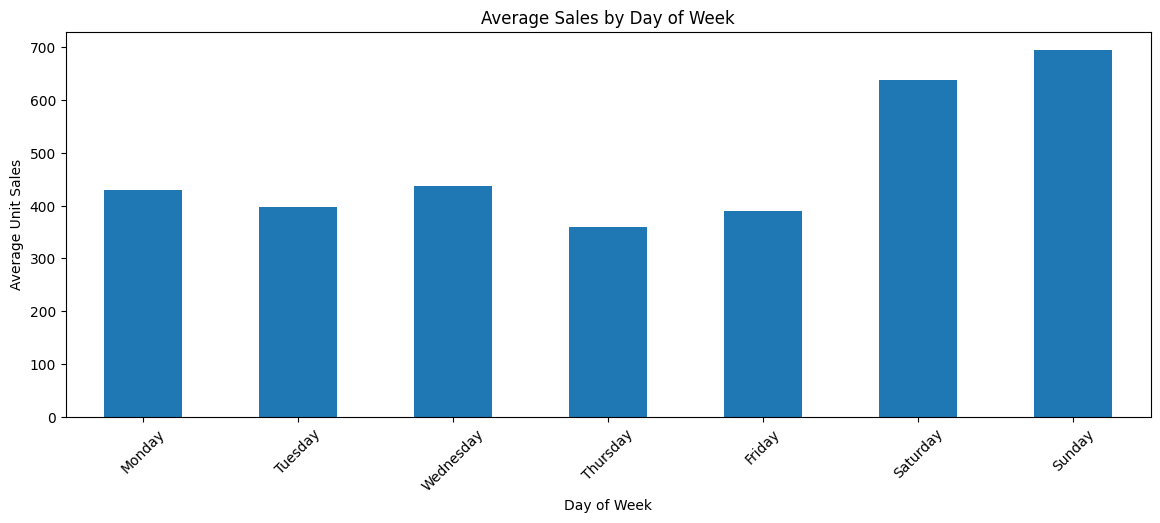

,unit_sales
day_name,
Monday,429.97
Tuesday,397.72
Wednesday,437.09
Thursday,359.66
Friday,389.23
Saturday,636.83
Sunday,694.09


In [ ]:
weekday_df = ts_df.copy()
weekday_df["dayofweek"] = weekday_df.index.dayofweek
weekday_df["day_name"] = weekday_df.index.day_name()

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
avg_by_day = weekday_df.groupby("day_name")["unit_sales"].mean().reindex(weekday_order)

plt.figure()
avg_by_day.plot(kind="bar")
plt.title("Average Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Unit Sales")
plt.xticks(rotation=45)
plt.grid(False)
plt.show()

avg_by_day.round(2)

Aim

Check if sales depend on the day of the week.

Results

Saturday and Sunday have the highest sales.

###interpretation

Customers buy more on weekends.

Conclusion

The dataset has strong weekly seasonality.

## 12. Monthly Seasonality Detection

**Aim:** Check whether sales differ by month.

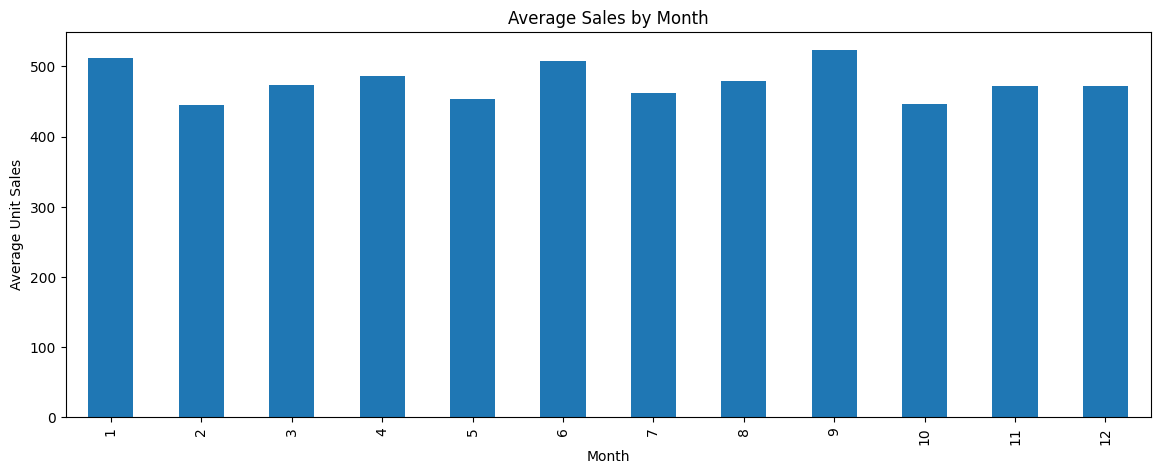

,unit_sales
month,
1,512.80
2,445.30
3,473.19
4,486.30
5,453.03
6,508.53
7,462.55
8,478.61
9,523.10


In [ ]:
month_df = ts_df.copy()
month_df["month"] = month_df.index.month
avg_by_month = month_df.groupby("month")["unit_sales"].mean()

plt.figure()
avg_by_month.plot(kind="bar")
plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Unit Sales")
plt.grid(False)
plt.show()

avg_by_month.round(2)

###interpretation

Some months are higher than others.

Higher months include: January, June. September

Lower months include: February, May, October

But the monthly pattern is not as strong as the weekly pattern.

**Conclusion:** Weekly seasonality is stronger than monthly seasonality.

## 13. Autocorrelation Analysis — ACF

ACF tells us whether sales today are related to sales from previous days.

Important lags for daily retail data are often 7, 14, 21, and 28 because they represent weekly repetition.

<Figure size 1400x500 with 0 Axes>

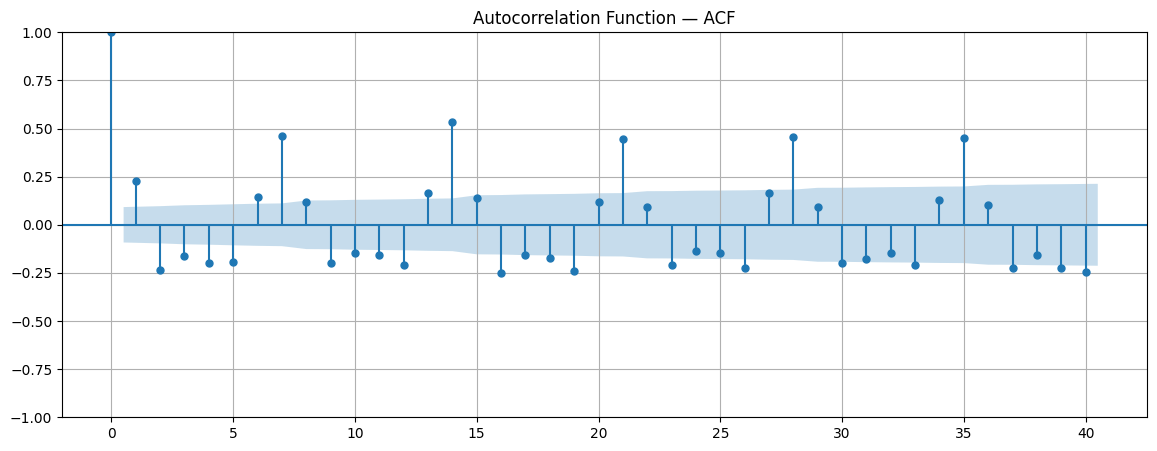

In [ ]:
plt.figure()
plot_acf(ts, lags=40)
plt.title("Autocorrelation Function — ACF")
plt.show()


###Interpretation:

Strong peaks around:
7
14
21

confirm: weekly repetition exists.

**Conclusion:**

The ACF helps confirm that past values, especially weekly lags, are useful for forecasting.

## 14. Partial Autocorrelation Analysis — PACF

PACF shows which past lags have a more direct relationship with current sales.
Aim

Find which past days directly influence today’s sales.

<Figure size 1400x500 with 0 Axes>

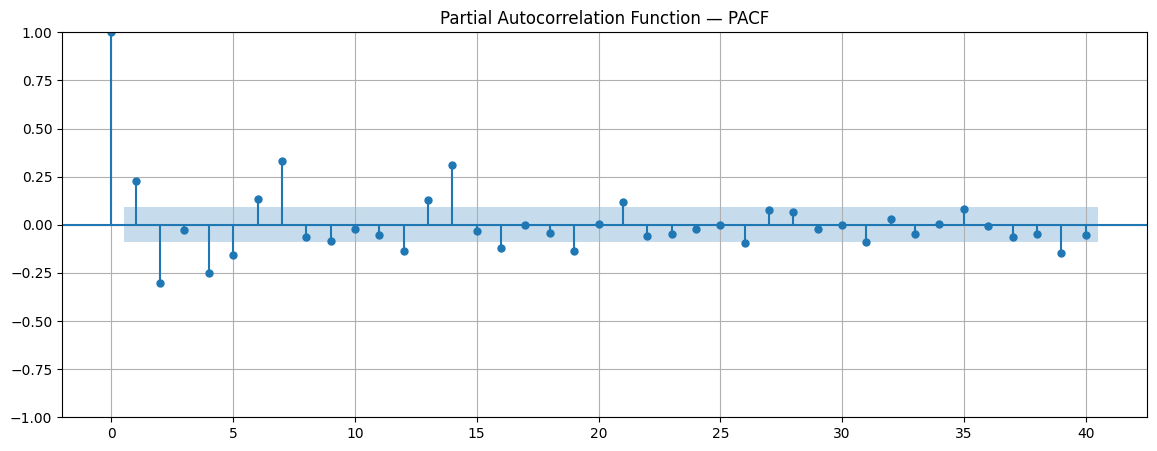

In [ ]:
plt.figure()
plot_pacf(ts, lags=40, method="ywm")
plt.title("Partial Autocorrelation Function — PACF")
plt.show()


###Interpretation:
Some previous days have direct predictive power.

## 15. Prepare Feature-Rich Dataset for Models

We prepare exogenous variables for SARIMAX and Prophet-style models.

Possible external drivers:
- oil price
- holidays
- day of week
- month
- weekend flag

In [ ]:
model_df = df.copy()

# Keep only numeric columns for modeling. Text columns such as holiday descriptions cannot be averaged.
numeric_cols_for_model = model_df.select_dtypes(include=[np.number]).columns.tolist()
model_df = model_df[["date"] + numeric_cols_for_model]
model_df = model_df.groupby("date", as_index=False).mean(numeric_only=True)
model_df = model_df.sort_values("date")
model_df = model_df.set_index("date").asfreq("D")

# Ensure target is filled
model_df["unit_sales"] = model_df["unit_sales"].interpolate().ffill().bfill()

# Add/fix time features
model_df["dayofweek"] = model_df.index.dayofweek
model_df["month"] = model_df.index.month
model_df["is_weekend"] = (model_df.index.dayofweek >= 5).astype(int)

# Fill useful exogenous variables if present
if "dcoilwtico" in model_df.columns:
    model_df["dcoilwtico"] = model_df["dcoilwtico"].interpolate().ffill().bfill()

for col in model_df.columns:
    if col.startswith("is_") or "holiday" in col.lower():
        model_df[col] = model_df[col].fillna(0)

# Select available exogenous variables
candidate_exog = ["dcoilwtico", "dayofweek", "month", "is_weekend", "is_holiday", "is_national_holiday", "is_regional_holiday", "is_local_holiday"]
exog_cols = [c for c in candidate_exog if c in model_df.columns]

print("Exogenous variables used:", exog_cols)
model_df[["unit_sales"] + exog_cols].head()


Exogenous variables used: ['dcoilwtico', 'dayofweek', 'month', 'is_weekend', 'is_holiday', 'is_national_holiday', 'is_regional_holiday', 'is_local_holiday']


,unit_sales,dcoilwtico,dayofweek,month,is_weekend,is_holiday,is_national_holiday,is_regional_holiday,is_local_holiday
date,,,,,,,,,
2013-01-02,582.0,93.140000,2,1,0,0.0,0.0,0.0,0.0
2013-01-03,310.0,92.970000,3,1,0,0.0,0.0,0.0,0.0
2013-01-04,338.0,93.120000,4,1,0,0.0,0.0,0.0,0.0
2013-01-05,654.0,93.146667,5,1,1,1.0,1.0,0.0,0.0
2013-01-06,979.0,93.173333,6,1,1,0.0,0.0,0.0,0.0


## 16. Correlation / Simple Feature Importance

Check which features are most related to sales.

Top positive correlations with unit_sales:
unit_sales             1.000000
is_weekend             0.689818
unit_sales_lag_14      0.571682
dayofweek              0.506974
unit_sales_lag_7       0.469853
sales_outlier_flag     0.365352
unit_sales_lag_1       0.233303
is_national_holiday    0.093726
is_month_start         0.067319
holiday_count          0.063605
Name: unit_sales, dtype: float64

Top negative correlations with unit_sales:
dcoilwtico                -0.000946
month                     -0.014507
quarter                   -0.017722
unit_sales_roll_mean_30   -0.022600
is_month_end              -0.025358
week_of_year              -0.034351
unit_sales_roll_std_30    -0.058955
is_regional_holiday       -0.063636
day                       -0.094808
unit_sales_lag_30         -0.244552
Name: unit_sales, dtype: float64


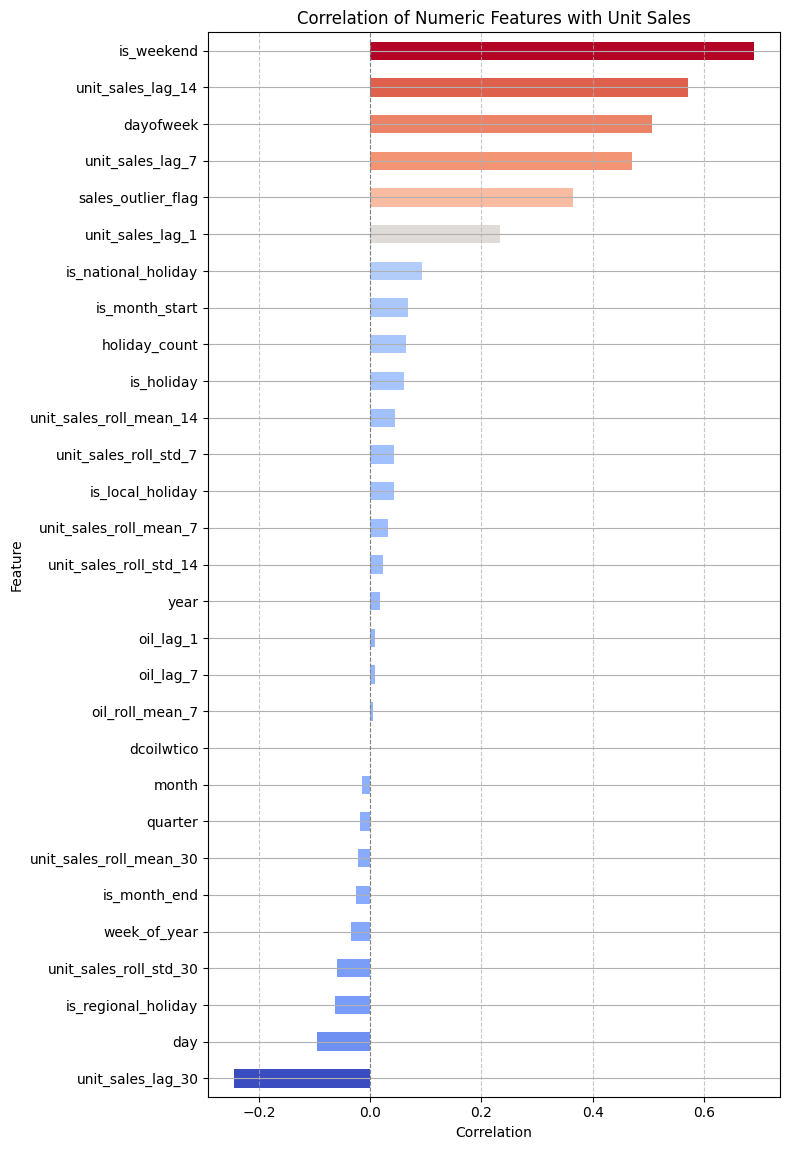

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CLEAN_PATH = "week1_clean_full.csv"
RAW_PATH = "timeseries.csv"

if os.path.exists(CLEAN_PATH):
    df = pd.read_csv(CLEAN_PATH)
elif os.path.exists(RAW_PATH):
    df = pd.read_csv(RAW_PATH)
else:
    raise FileNotFoundError("No input data found. Please place week1_clean_full.csv or timeseries.csv in the same folder.")

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

model_df = df.copy()

# Keep only numeric columns for modeling. Text columns such as holiday descriptions cannot be averaged.
numeric_cols_for_model = model_df.select_dtypes(include=[np.number]).columns.tolist()
model_df = model_df[["date"] + numeric_cols_for_model]
model_df = model_df.groupby("date", as_index=False).mean(numeric_only=True)
model_df = model_df.sort_values("date")
model_df = model_df.set_index("date").asfreq("D")

# Ensure target is filled
model_df["unit_sales"] = model_df["unit_sales"].interpolate().ffill().bfill()

# Add/fix time features
model_df["dayofweek"] = model_df.index.dayofweek
model_df["month"] = model_df.index.month
model_df["is_weekend"] = (model_df.index.dayofweek >= 5).astype(int)

# Fill useful exogenous variables if present
if "dcoilwtico" in model_df.columns:
    model_df["dcoilwtico"] = model_df["dcoilwtico"].interpolate().ffill().bfill()

for col in model_df.columns:
    if col.startswith("is_") or "holiday" in col.lower():
        model_df[col] = model_df[col].fillna(0)

# Select available exogenous variables
candidate_exog = ["dcoilwtico", "dayofweek", "month", "is_weekend", "is_holiday", "is_national_holiday", "is_regional_holiday", "is_local_holiday"]
exog_cols = [c for c in candidate_exog if c in model_df.columns]

numeric_cols = model_df.select_dtypes(include=[np.number]).columns.tolist()
correlations = model_df[numeric_cols].corr(numeric_only=True)["unit_sales"].sort_values(ascending=False)

print("Top positive correlations with unit_sales:")
print(correlations.head(10))
print()
print("Top negative correlations with unit_sales:")
print(correlations.tail(10))

# Prepare data for plotting
correlations_for_plot = correlations.drop("unit_sales", errors="ignore").sort_values()

# Create a colormap and normalize correlation values for coloring
cmap = plt.cm.coolwarm  # Diverging colormap for positive and negative correlations
norm = plt.Normalize(vmin=correlations_for_plot.min(), vmax=correlations_for_plot.max())

plt.figure(figsize=(8, max(5, len(correlations_for_plot) * 0.4))) # Adjust figsize dynamically
bars = correlations_for_plot.plot(kind="barh", color=cmap(norm(correlations_for_plot)))
plt.title("Correlation of Numeric Features with Unit Sales")
plt.xlabel("Correlation")
plt.ylabel("Feature") # Added y-label for clarity
plt.axvline(x=0, color='grey', linestyle='--', linewidth=0.8) # Add a vertical line at 0
plt.grid(axis='x', linestyle='--', alpha=0.7) # Add grid for x-axis
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

###Interpretation:
Weekend effects and past sales are important.

## 17. Chronological Train/Test Split

For forecasting, we never randomly split time series data.

We train on the past and test on the future.

Train: 2013-01-02 00:00:00 to 2013-12-31 00:00:00 | rows: 364
Test: 2014-01-01 00:00:00 to 2014-03-31 00:00:00 | rows: 90


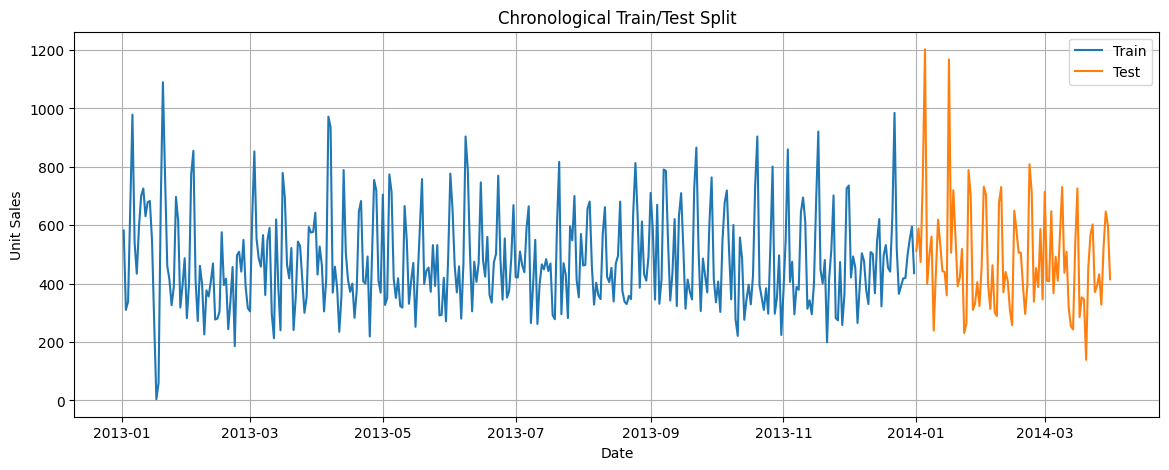

In [ ]:
TEST_DAYS = 90
train = model_df.iloc[:-TEST_DAYS].copy()
test = model_df.iloc[-TEST_DAYS:].copy()

y_train = train["unit_sales"]
y_test = test["unit_sales"]

X_train = train[exog_cols] if exog_cols else None
X_test = test[exog_cols] if exog_cols else None

print("Train:", train.index.min(), "to", train.index.max(), "| rows:", len(train))
print("Test:", test.index.min(), "to", test.index.max(), "| rows:", len(test))

plt.figure()
plt.plot(y_train, label="Train")
plt.plot(y_test, label="Test")
plt.title("Chronological Train/Test Split")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.legend()
plt.show()


## 18. Evaluation Function
We evaluate baseline forecasts using:

- **MAE**: Mean Absolute Error  
- **RMSE**: Root Mean Squared Error  
- **MAPE**: Mean Absolute Percentage Error  

Baseline models are important because advanced models should outperform them.

**WHY BASELINES MATTER**

Before advanced AI models,
we need simple references.

In [ ]:
def evaluate_forecast(model_name, actual, predicted):
    actual = pd.Series(actual).astype(float)
    predicted = pd.Series(predicted, index=actual.index).astype(float)
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual.replace(0, np.nan))) * 100
    r2 = r2_score(actual, predicted)
    return {"Model": model_name, "MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2}

def plot_forecast(model_name, train_series, test_series, prediction):
    prediction = pd.Series(prediction, index=test_series.index)
    plt.figure()
    plt.plot(train_series, label="Train")
    plt.plot(test_series, label="Actual test")
    plt.plot(prediction, label=f"{model_name} forecast")
    plt.title(model_name)
    plt.xlabel("Date")
    plt.ylabel("Unit Sales")
    plt.legend()
    plt.show()

results = []


## 19. Baseline Models

These are simple benchmark models. Advanced models should try to beat them.

**Naive forecast**: it predicts that tomorrow's sales will be equal to the most recent observed sales value. Use the last known sales value as the forecast.

Formula:[ \hat{y}_{t+1} = y_t ]

**Seasonal naive forecast**: Predict today using the value from the same day last week.

**Moving average forecast**: Predict using the average of recent observations.

Here we use the last 7 days of the training data as the forecast value.

This model predicts future sales using the average of the last 7 training days.

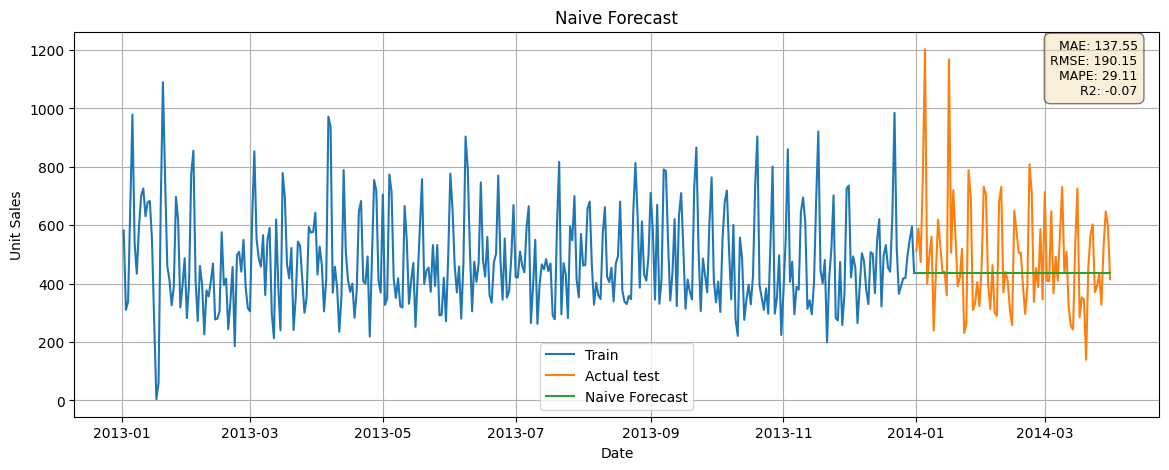

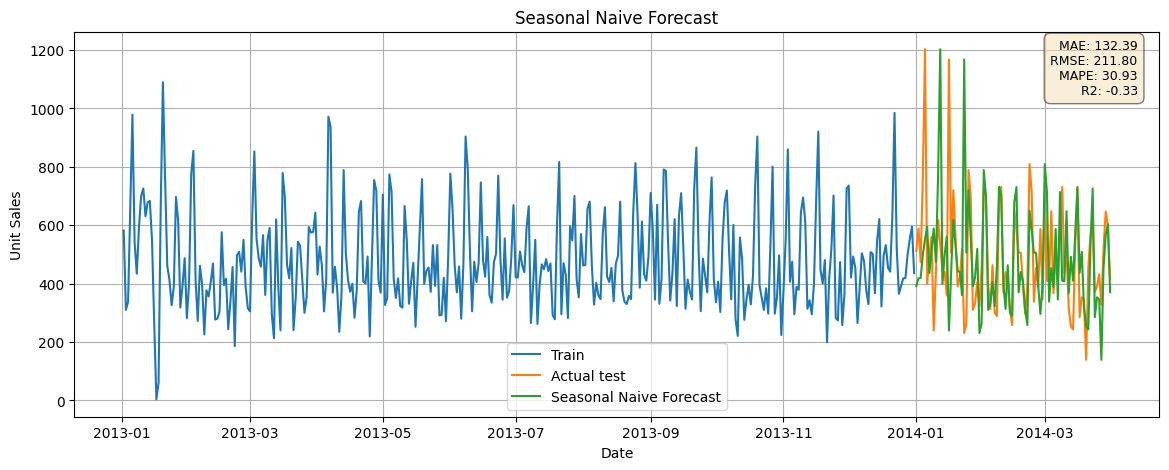

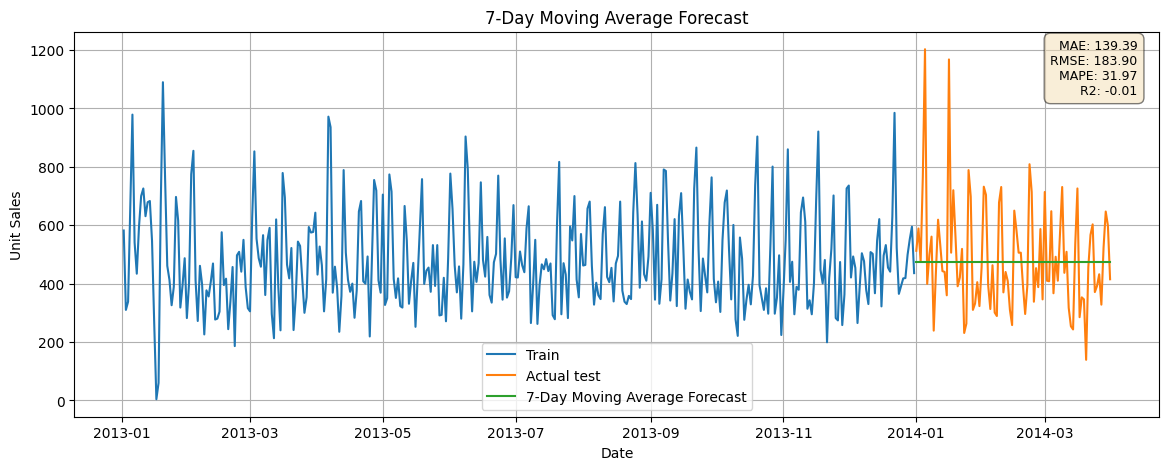

In [ ]:
# Naive forecast: all future test values equal the last training value
naive_pred = pd.Series([y_train.iloc[-1]] * len(y_test), index=y_test.index)
naive_eval = evaluate_forecast("Naive Forecast", y_test, naive_pred)
results.append(naive_eval)

# Inline plot for Naive Forecast with metrics
prediction_series_naive = pd.Series(naive_pred, index=y_test.index)
plt.figure()
plt.plot(y_train, label="Train")
plt.plot(y_test, label="Actual test")
plt.plot(prediction_series_naive, label="Naive Forecast")
plt.title("Naive Forecast")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.legend()
metrics_text_naive = (
    f"MAE: {naive_eval['MAE']:.2f}\n"
    f"RMSE: {naive_eval['RMSE']:.2f}\n"
    f"MAPE: {naive_eval['MAPE']:.2f}\n"
    f"R2: {naive_eval['R2']:.2f}"
)
plt.text(0.98, 0.98, metrics_text_naive, transform=plt.gca().transAxes,
         fontsize=9, verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))
plt.show()

# Seasonal naive: repeat value from 7 days ago
seasonal_naive_values = []
history = y_train.copy()
for date in y_test.index:
    lag_date = date - pd.Timedelta(days=7)
    if lag_date in history.index:
        pred = history.loc[lag_date]
    else:
        pred = history.iloc[-7:].mean()
    seasonal_naive_values.append(pred)
    history.loc[date] = y_test.loc[date]
seasonal_naive_pred = pd.Series(seasonal_naive_values, index=y_test.index)
seasonal_naive_eval = evaluate_forecast("Seasonal Naive 7-day", y_test, seasonal_naive_pred)
results.append(seasonal_naive_eval)

# Inline plot for Seasonal Naive Forecast with metrics
prediction_series_seasonal = pd.Series(seasonal_naive_pred, index=y_test.index)
plt.figure()
plt.plot(y_train, label="Train")
plt.plot(y_test, label="Actual test")
plt.plot(prediction_series_seasonal, label="Seasonal Naive Forecast")
plt.title("Seasonal Naive Forecast")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.legend()
metrics_text_seasonal = (
    f"MAE: {seasonal_naive_eval['MAE']:.2f}\n"
    f"RMSE: {seasonal_naive_eval['RMSE']:.2f}\n"
    f"MAPE: {seasonal_naive_eval['MAPE']:.2f}\n"
    f"R2: {seasonal_naive_eval['R2']:.2f}"
)
plt.text(0.98, 0.98, metrics_text_seasonal, transform=plt.gca().transAxes,
         fontsize=9, verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))
plt.show()

# 7-day moving average
ma7_value = y_train.iloc[-7:].mean()
ma7_pred = pd.Series([ma7_value] * len(y_test), index=y_test.index)
moving_average_eval = evaluate_forecast("7-Day Moving Average", y_test, ma7_pred)
results.append(moving_average_eval)

# Inline plot for 7-Day Moving Average Forecast with metrics
prediction_series_ma7 = pd.Series(ma7_pred, index=y_test.index)
plt.figure()
plt.plot(y_train, label="Train")
plt.plot(y_test, label="Actual test")
plt.plot(prediction_series_ma7, label="7-Day Moving Average Forecast")
plt.title("7-Day Moving Average Forecast")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.legend()
metrics_text_ma7 = (
    f"MAE: {moving_average_eval['MAE']:.2f}\n"
    f"RMSE: {moving_average_eval['RMSE']:.2f}\n"
    f"MAPE: {moving_average_eval['MAPE']:.2f}\n"
    f"R2: {moving_average_eval['R2']:.2f}"
)
plt.text(0.98, 0.98, metrics_text_ma7, transform=plt.gca().transAxes,
         fontsize=9, verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))
plt.show()

###Interpretation Naive Forecast:
The naive forecast is a basic benchmark.

It does not understand weekly seasonality.

But it gives us a minimum standard. Surprisingly effective in many time series.

Here it performs reasonably well because: nearby days are similar.

###Interpretation Seasonal Naive Forecast:
This model understands weekly repetition. Useful because the dataset has strong weekly seasonality.

Its MAE is slightly better than naive, but RMSE and MAPE are worse.

It sometimes makes large mistakes, probably because some weeks have unusual spikes or drops.

###Interpretation Moving Average Forecast:
This model is smoother.

It does not follow spikes well, but it gives a stable forecast.

It has the best MAPE but not the best RMSE.

## 20. Simple Exponential Smoothing

This model gives more weight to recent observations than older ones.

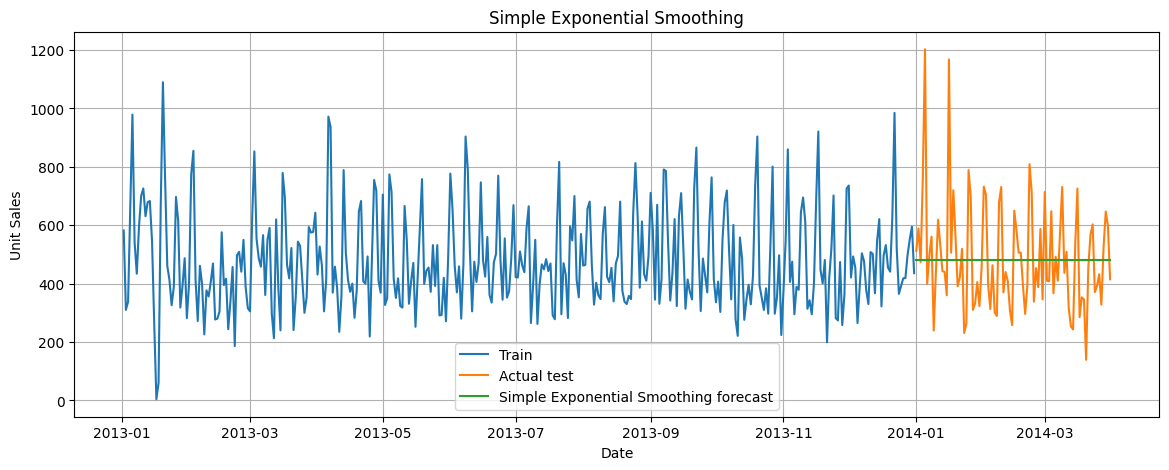

In [ ]:
ses_model = SimpleExpSmoothing(y_train).fit(optimized=True)
ses_pred = ses_model.forecast(len(y_test))
ses_pred.index = y_test.index
results.append(evaluate_forecast("Simple Exponential Smoothing", y_test, ses_pred))
plot_forecast("Simple Exponential Smoothing", y_train, y_test, ses_pred)


## 21. Holt Linear Trend Model

Holt's model adds a trend component. It is useful if the series has a clear upward or downward direction.

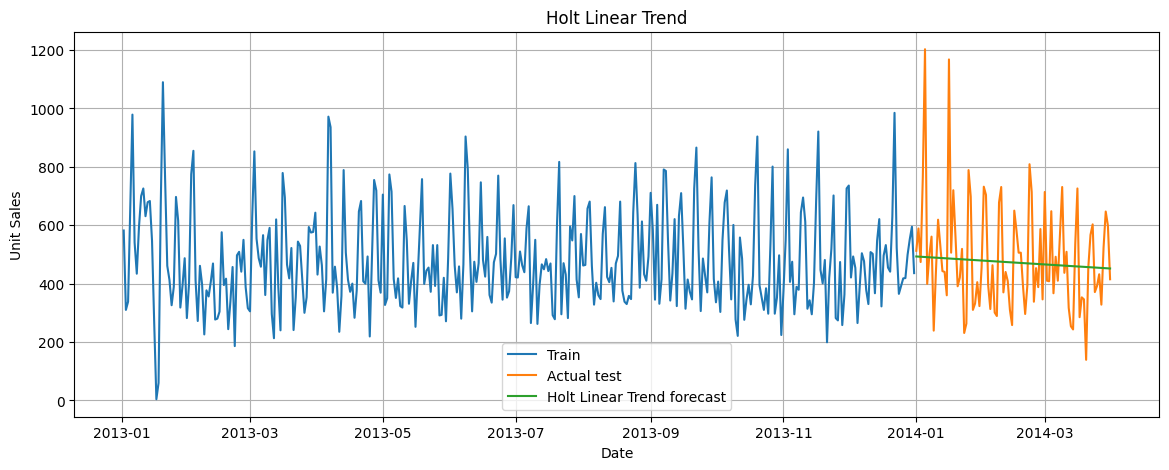

In [ ]:
holt_model = Holt(y_train).fit(optimized=True)
holt_pred = holt_model.forecast(len(y_test))
holt_pred.index = y_test.index
results.append(evaluate_forecast("Holt Linear Trend", y_test, holt_pred))
plot_forecast("Holt Linear Trend", y_train, y_test, holt_pred)


Useful when trend exists, but our dataset has stronger weekly seasonality than trend.

## 22. Holt-Winters Seasonal Exponential Smoothing

This model handles level, trend, and weekly seasonality.

Because our data is daily and weekly patterns are visible, we use `seasonal_periods=7`.

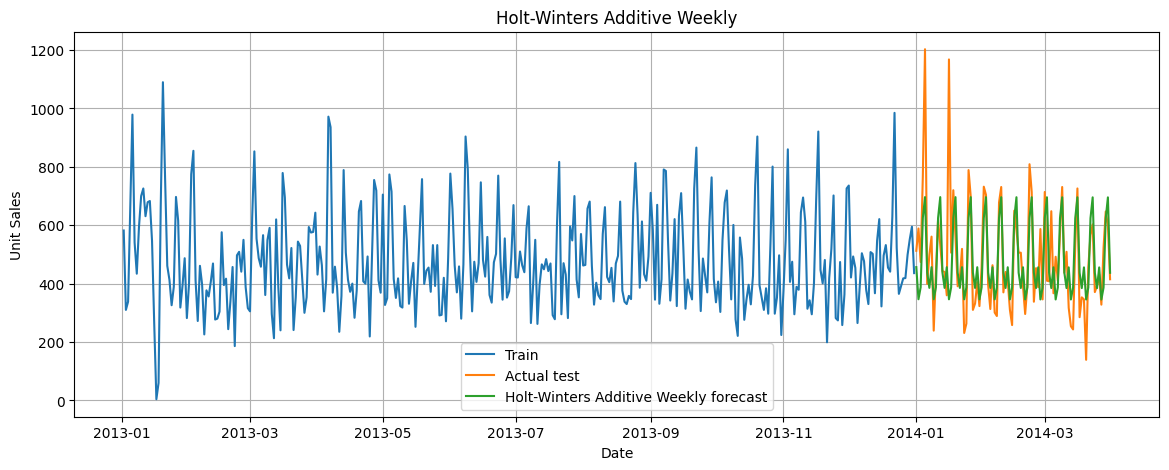

In [ ]:
hw_model = ExponentialSmoothing(
    y_train,
    trend="add",
    seasonal="add",
    seasonal_periods=7
).fit(optimized=True)

hw_pred = hw_model.forecast(len(y_test))
hw_pred.index = y_test.index
results.append(evaluate_forecast("Holt-Winters Additive Weekly", y_test, hw_pred))
plot_forecast("Holt-Winters Additive Weekly", y_train, y_test, hw_pred)


###Interpretation:

This model understands that weekends behave differently from weekdays.

Conclusion

Holt-Winters is very suitable for this dataset.

## 23. SARIMAX / ARIMA-Style Model

We use SARIMAX because it can include:
- autoregressive behavior
- moving average behavior
- weekly seasonality
- external regressors such as oil and holidays

WHY IMPORTANT HERE?

Our dataset contains:

* weekly seasonality

* holidays


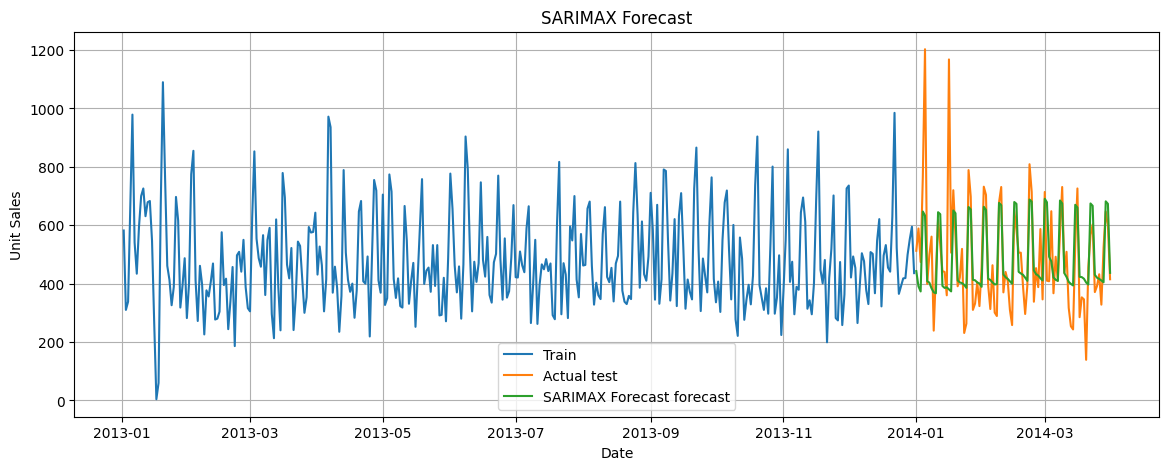

                                     SARIMAX Results                                     
Dep. Variable:                        unit_sales   No. Observations:                  364
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 7)   Log Likelihood               -2181.878
Date:                           Tue, 12 May 2026   AIC                           4389.757
Time:                                   19:35:57   BIC                           4440.094
Sample:                               01-02-2013   HQIC                          4409.782
                                    - 12-31-2013                                         
Covariance Type:                             opg                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
dcoilwtico              4.3420      0.211     20.582      0.000       3.929       4.755
dayofweek       

In [ ]:
# Simple SARIMAX specification for a stationary series with weekly seasonality
# Since ADF/KPSS suggest stationarity, d=0 is reasonable.
# Seasonal order includes weekly period = 7.
try:
    sarimax_model = SARIMAX(
        y_train,
        exog=X_train,
        order=(1, 0, 1),
        seasonal_order=(1, 0, 1, 7),
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)

    sarimax_pred = sarimax_model.forecast(steps=len(y_test), exog=X_test)
    sarimax_pred.index = y_test.index
    results.append(evaluate_forecast("SARIMAX (1,0,1)(1,0,1,7)", y_test, sarimax_pred))
    plot_forecast("SARIMAX Forecast", y_train, y_test, sarimax_pred)
    print(sarimax_model.summary())
except Exception as e:
    print("SARIMAX failed:", e)


###Interpretation:

SARIMAX follows the real sales pattern better than simpler models.

**Conclusion**

SARIMAX is one of the strongest models in this notebook.

## 24. SARIMAX Residual Diagnostics

Check the model errors over time.

A good model should leave residuals that look mostly random.

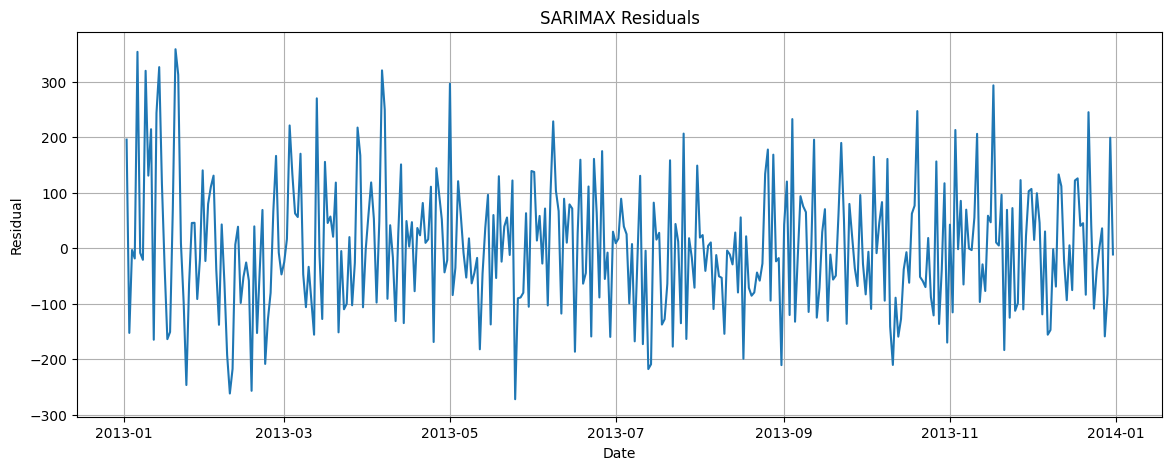

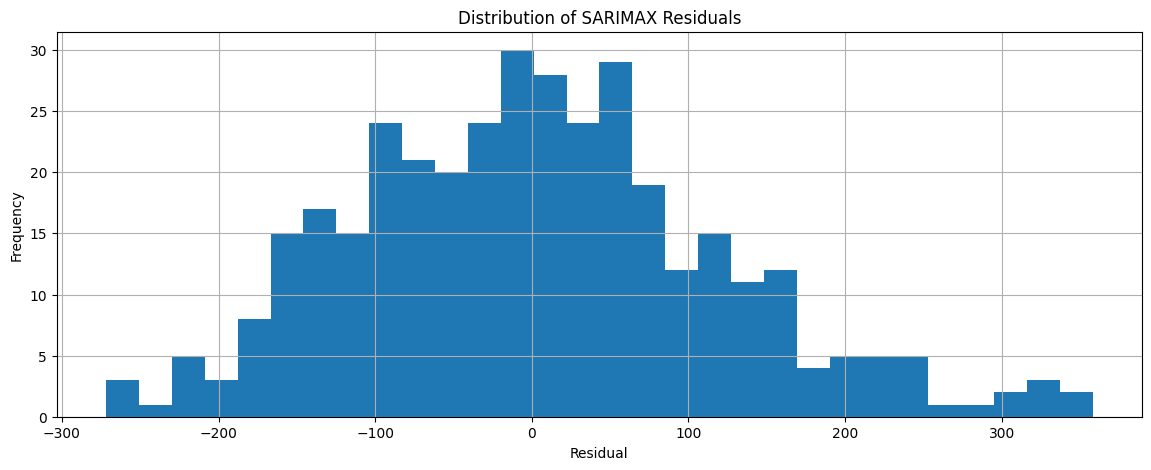

<Figure size 1400x500 with 0 Axes>

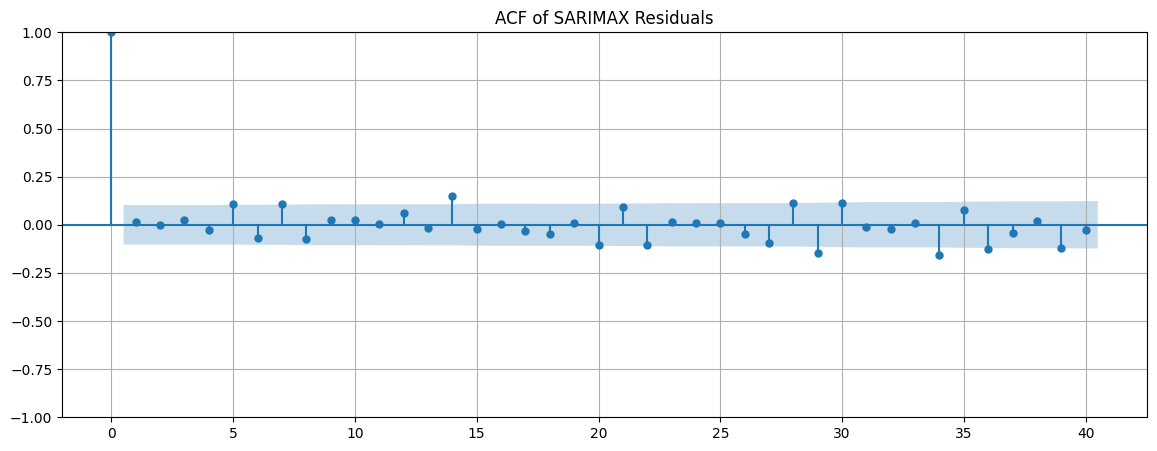

In [ ]:
if "sarimax_model" in globals():
    residuals = sarimax_model.resid.dropna()
    plt.figure()
    plt.plot(residuals)
    plt.title("SARIMAX Residuals")
    plt.xlabel("Date")
    plt.ylabel("Residual")
    plt.show()

    plt.figure()
    residuals.hist(bins=30)
    plt.title("Distribution of SARIMAX Residuals")
    plt.xlabel("Residual")
    plt.ylabel("Frequency")
    plt.show()

    plt.figure()
    plot_acf(residuals, lags=40)
    plt.title("ACF of SARIMAX Residuals")
    plt.show()
else:
    print("SARIMAX model was not available, so residual diagnostics were skipped.")


###Interpretation:
Residuals are the difference between actual sales and predicted sales.

**Conclusion**

If residuals look random, the model captured most useful patterns.

## 25. Prophet Model — Optional
Prophet is:

+ easier
+ more automatic
+ beginner friendly

than ARIMA.Prophet requires columns named:
- `ds`: date
- `y`: value to forecast

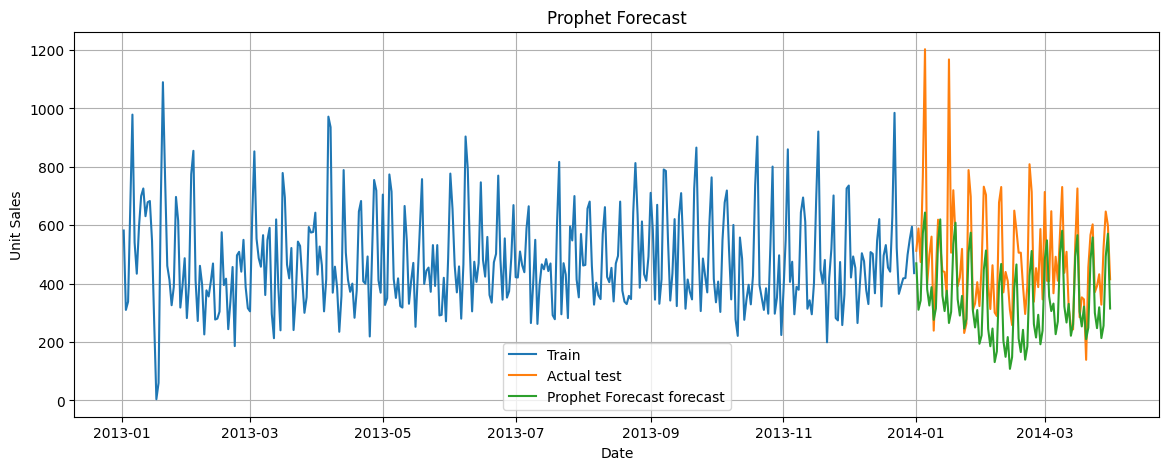

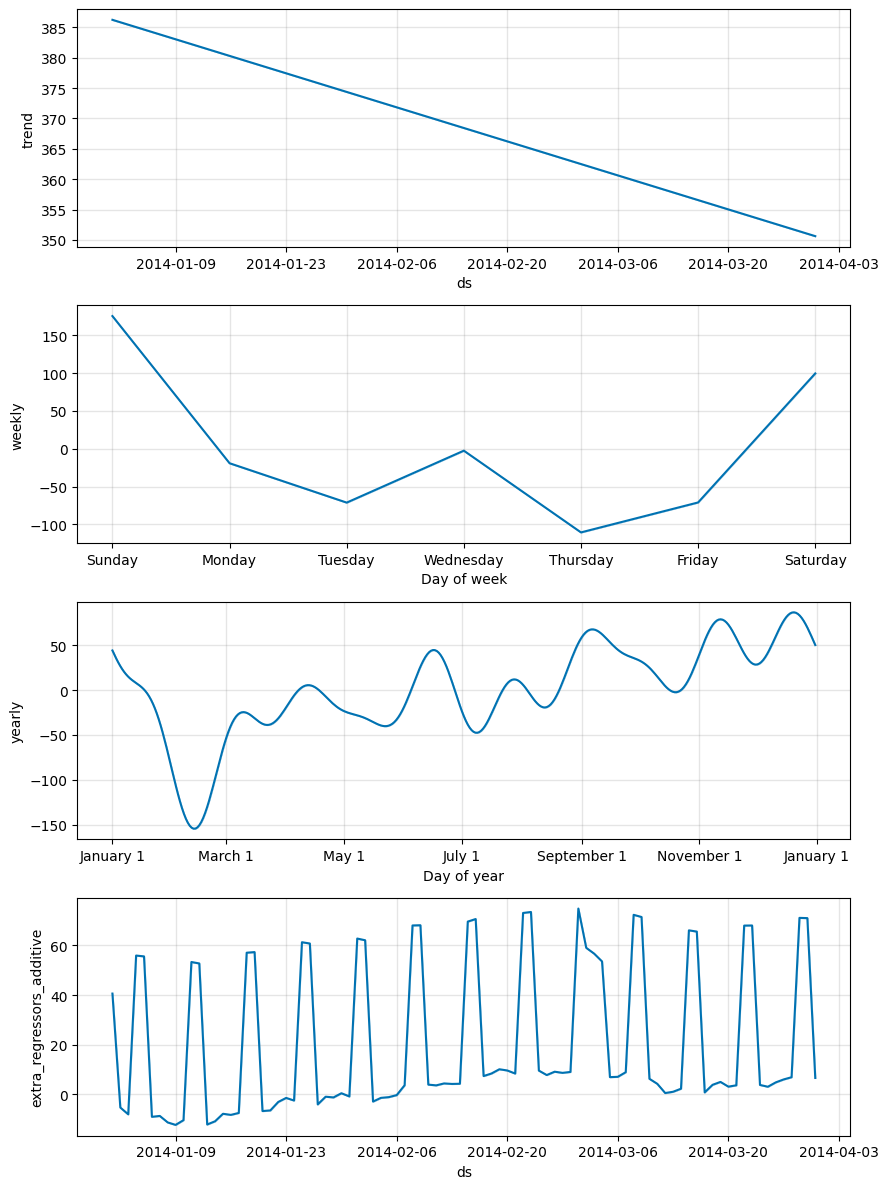

In [ ]:
try:
    from prophet import Prophet
    prophet_available = True
except Exception:
    prophet_available = False

if prophet_available:
    prophet_train = y_train.reset_index()
    prophet_train.columns = ["ds", "y"]
    prophet_test = y_test.reset_index()
    prophet_test.columns = ["ds", "y"]

    prophet_model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False
    )

    # Add regressors when possible
    prophet_exog_cols = [c for c in exog_cols if c not in ["dayofweek", "month"]]
    for col in prophet_exog_cols:
        prophet_model.add_regressor(col)
        prophet_train[col] = train[col].values

    prophet_model.fit(prophet_train)

    future = prophet_test[["ds"]].copy()
    for col in prophet_exog_cols:
        future[col] = test[col].values

    prophet_forecast = prophet_model.predict(future)
    prophet_pred = pd.Series(prophet_forecast["yhat"].values, index=y_test.index)
    results.append(evaluate_forecast("Prophet", y_test, prophet_pred))
    plot_forecast("Prophet Forecast", y_train, y_test, prophet_pred)

    fig = prophet_model.plot_components(prophet_forecast)
    plt.show()
else:
    print("Prophet is not installed in this environment. The notebook keeps this section as optional code.")


###Interpretation

Prophet gives a smooth forecast and tries to capture repeated patterns.

**Conclusion**

Prophet is useful and beginner-friendly, but in this notebook it does not outperform SARIMAX.

## 26. Model Comparison

Compare all models using RMSE.

Lower RMSE is better.

                          Model         MAE        RMSE       MAPE        R2
6      SARIMAX (1,0,1)(1,0,1,7)   93.696081  140.219509  21.771737  0.415622
5  Holt-Winters Additive Weekly   94.830388  143.070715  20.996911  0.391615
4             Holt Linear Trend  138.135008  182.068506  31.614656  0.014750
3  Simple Exponential Smoothing  140.501806  183.485354  32.787052 -0.000644
2          7-Day Moving Average  139.386508  183.900562  31.973708 -0.005178
0                Naive Forecast  137.550000  190.152548  29.108102 -0.074685
7                       Prophet  157.274163  203.227294  30.993891 -0.227555
1          Seasonal Naive 7-day  132.394444  211.801827  30.929721 -0.333326


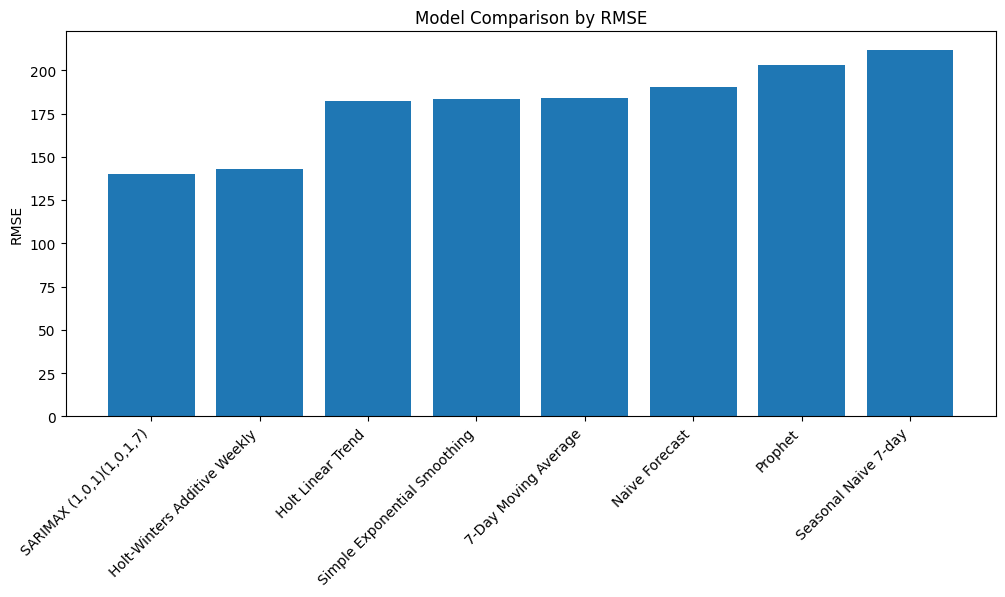

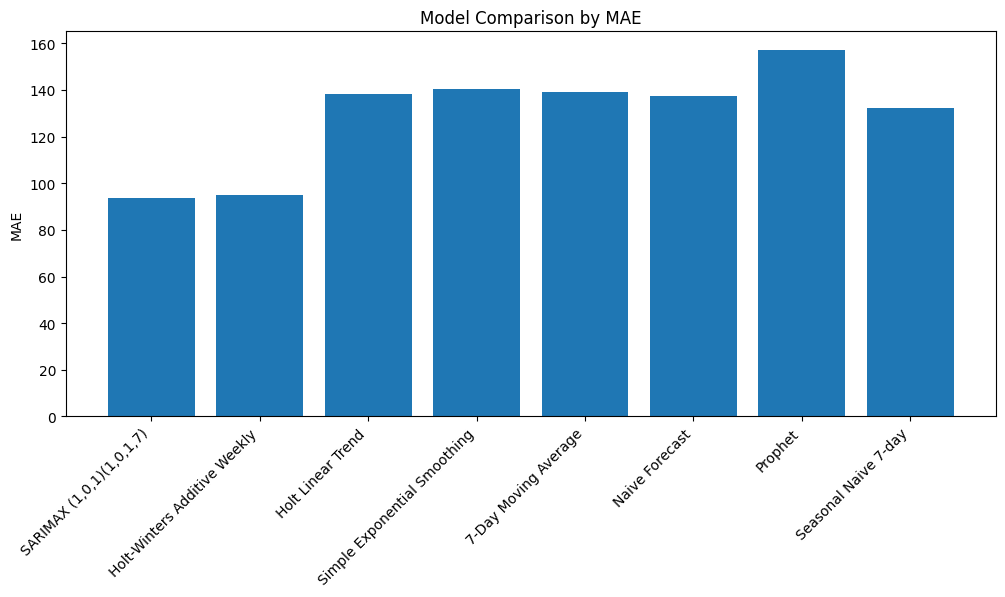

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
results_df = pd.DataFrame(results).sort_values("RMSE")
print(results_df)

plt.figure(figsize=(12, 5))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.title("Model Comparison by RMSE")
plt.ylabel("RMSE")
plt.xticks(rotation=45, ha="right")
plt.grid(False)
plt.show()

plt.figure(figsize=(12, 5))
plt.bar(results_df["Model"], results_df["MAE"])
plt.title("Model Comparison by MAE")
plt.ylabel("MAE")
plt.xticks(rotation=45, ha="right")
plt.grid(False)
plt.show()

results_df.to_csv("week2_model_comparison.csv", index=False)
results_df
from google.colab import files
files.download('week2_model_comparison.csv')

###Interpretation:

+ Best model: SARIMAX
+ Second: Holt-Winters
+ Worst among main models: Prophet / simple baselines


SARIMAX made the smallest large errors overall.

Conclusion

SARIMAX is the strongest model based on RMSE and MAE

## 27. Final Week 2 Interpretation Template

The Week 2 analysis showed that the daily sales series is statistically stationary based on the ADF and KPSS tests. Decomposition and weekday analysis revealed a strong weekly seasonal pattern, with higher sales during weekends. The ACF and PACF plots showed that previous observations, especially weekly lags, are useful for forecasting. Baseline models were created first to provide a benchmark. Additional statistical forecasting models were then tested, including Simple Exponential Smoothing, Holt, Holt-Winters, SARIMAX, and Prophet if available. The best model was selected based on RMSE and MAE. This gives a clear understanding of the time-series structure and prepares the project for more advanced forecasting in the next phase.
